In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload one or more images
uploaded = files.upload()


Saving cat.jpg to cat.jpg
Saving leaf.jpg to leaf.jpg
Saving lotus.jpg to lotus.jpg
Saving nature.jpg to nature.jpg
Saving sunflower.jpg to sunflower.jpg


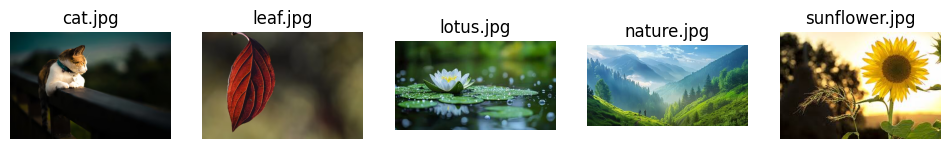

In [ ]:
images = []
for filename in uploaded.keys():
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append((filename, img))

# Display all images
plt.figure(figsize=(12, 6))
for i, (name, img) in enumerate(images):
    plt.subplot(1, len(images), i+1)
    plt.imshow(img)
    plt.title(name)
    plt.axis('off')
plt.show()


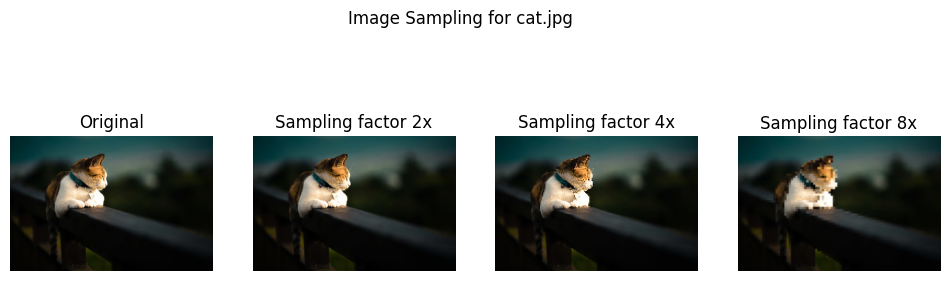

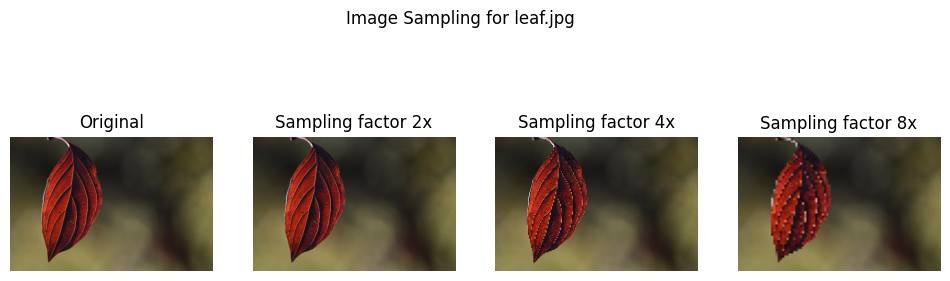

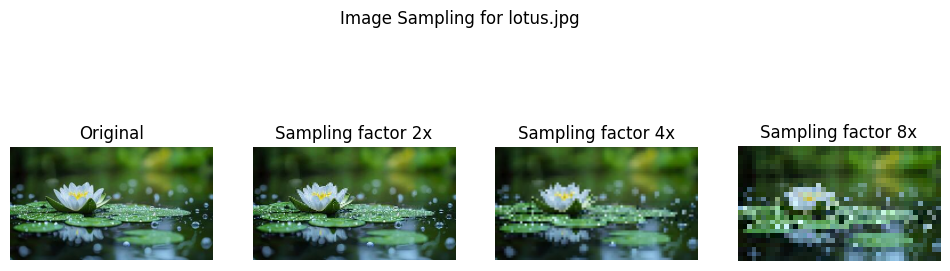

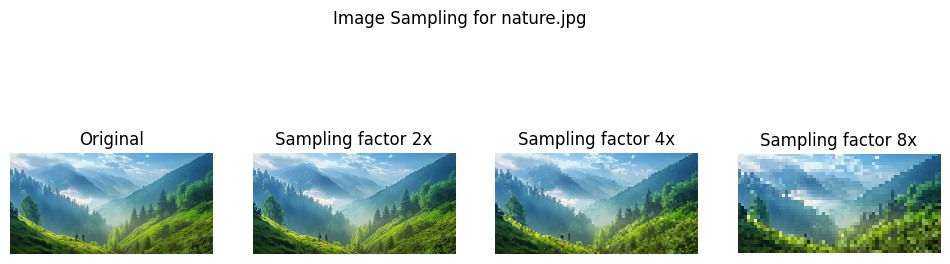

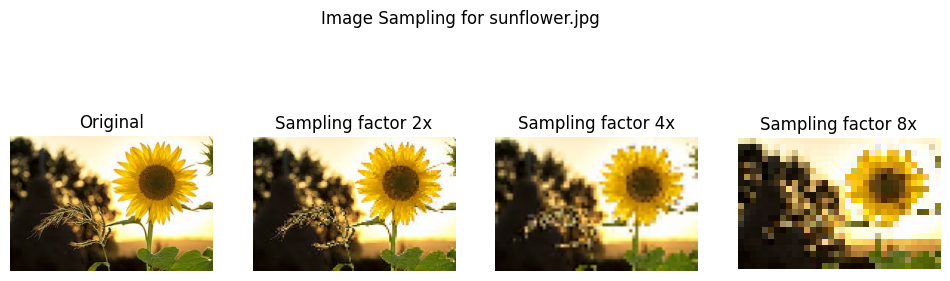

In [ ]:
def sample_image(img, factor):
    h, w = img.shape[:2]
    sampled = cv2.resize(img, (w//factor, h//factor), interpolation=cv2.INTER_NEAREST)
    return sampled

sample_factors = [2, 4, 8]  # 2x, 4x, 8x downsampling

for name, img in images:
    plt.figure(figsize=(12,4))
    plt.subplot(1, len(sample_factors)+1, 1)
    plt.imshow(img)
    plt.title('Original')
    plt.axis('off')

    for i, f in enumerate(sample_factors):
        sampled = sample_image(img, f)
        plt.subplot(1, len(sample_factors)+1, i+2)
        plt.imshow(sampled)
        plt.title(f'Sampling factor {f}x')
        plt.axis('off')
    plt.suptitle(f"Image Sampling for {name}")
    plt.show()


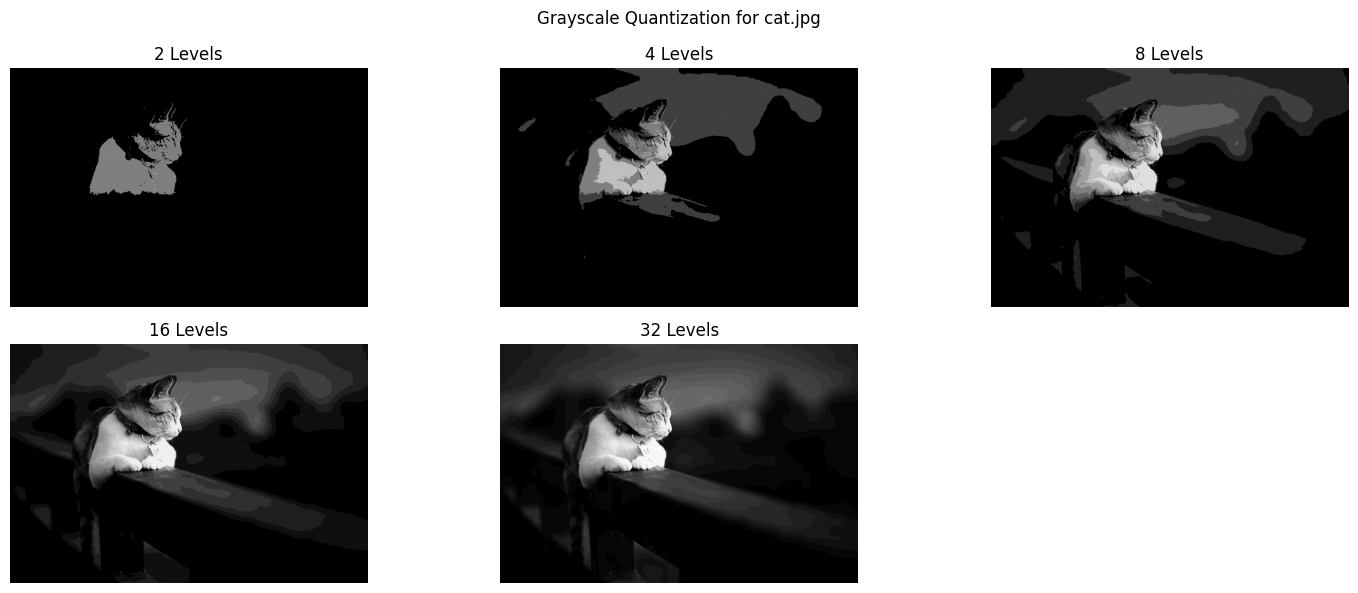

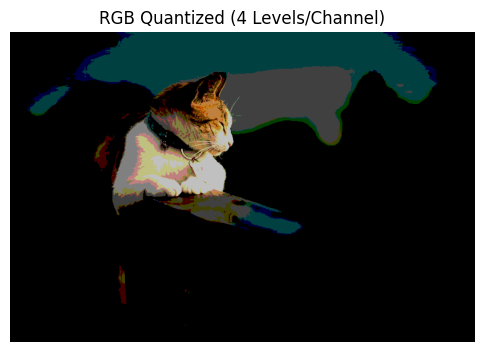

Unique levels in each RGB channel:
R: [  0  64 128 192]
G: [  0  64 128 192]
B: [  0  64 128 192]

Unique levels in each HSV channel:
H: [  0  10  15  20  30  60  90 120 150]
S: [  0  85 128 170 255]
V: [  0  64 128 192]


In [ ]:
# ------------------ Quantization ------------------

# Function to quantize image (grayscale or color)
def quantize_image(img, levels):
    img_norm = img / 255.0
    quantized = np.floor(img_norm * levels) / levels
    quantized = np.uint8(quantized * 255)
    return quantized

# Convert one of the images to grayscale for grayscale quantization
name, image = images[0]   # Use first uploaded image
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Different quantization levels
quant_levels = [2, 4, 8, 16, 32]

plt.figure(figsize=(15, 6))
for i, level in enumerate(quant_levels):
    quant = quantize_image(gray, level)
    plt.subplot(2, 3, i+1)
    plt.imshow(quant, cmap='gray')
    plt.title(f"{level} Levels")
    plt.axis('off')

plt.suptitle(f"Grayscale Quantization for {name}")
plt.tight_layout()
plt.show()


# ------------------ Color Model Quantization ------------------

# Quantization in RGB (reduce to 4 levels per channel)
quant_rgb = (image // 64) * 64   # 256/64 = 4 levels per channel (0, 64, 128, 192)
plt.figure(figsize=(6,6))
plt.imshow(quant_rgb)
plt.title("RGB Quantized (4 Levels/Channel)")
plt.axis('off')
plt.show()


# Function to analyze quantized levels
def analyze_quantized_levels(img, model='RGB'):
    if model == 'RGB':
        print("Unique levels in each RGB channel:")
        for i, ch in enumerate(['R', 'G', 'B']):
            unique_vals = np.unique(img[:,:,i])
            print(f"{ch}: {unique_vals}")
    elif model == 'HSV':
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        print("\nUnique levels in each HSV channel:")
        for i, ch in enumerate(['H', 'S', 'V']):
            unique_vals = np.unique(hsv[:,:,i])
            print(f"{ch}: {unique_vals}")

# Analyze quantized color levels
analyze_quantized_levels(quant_rgb, 'RGB')
analyze_quantized_levels(quant_rgb, 'HSV')
